<a href="https://colab.research.google.com/github/Hkd225/Face-Shape-Classification-Hairstyle-Recommendation-/blob/main/face_shape_hairstyle_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# =========================
!pip -q install kagglehub mediapipe opencv-python-headless


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.5 MB/s eta 0:00:00


In [5]:
!pip install TensorFlow

In [33]:
# =========================
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import kagglehub

warnings.filterwarnings("ignore")

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

tf.keras.utils.set_random_seed(SEED)

os.makedirs("/content/data", exist_ok=True)
os.makedirs("/content/models", exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
# ==========================================
# 4) Download dataset via kagglehub

import kagglehub
from pathlib import Path

DATASET_HANDLE = "zeyadkhalid/faceshape-processed"

dataset_path = kagglehub.dataset_download(DATASET_HANDLE)

print("Dataset downloaded to:", dataset_path)

DATA_DIR = Path(dataset_path)

100%|██████████| 79.8M/79.8M [00:00<00:00, 145MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/zeyadkhalid/faceshape-processed/versions/1


In [10]:
def print_tree(root_dir, max_depth=3):
    root = Path(root_dir)

    for path in sorted(root.rglob("*")):
        depth = len(path.relative_to(root).parts)
        if depth > max_depth:
            continue

        indent = "  " * (depth - 1)

        if path.is_dir():
            print(f"{indent}{path.name}/")
        else:
            print(f"{indent}{path.name}")

print_tree(DATA_DIR)

dataset/
  test/
    Heart/
    Oblong/
    Oval/
    Round/
    Square/
  train/
    Heart/
    Oblong/
    Oval/
    Round/
    Square/


In [12]:
# ==========================================================
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

NUMERIC_LABEL_MAP = {
    "1": "heart",
    "2": "oblong",
    "3": "round",
    "4": "square",
    "5": "oval",
}

NAME_ALIASES = {
    "heart": "heart",
    "oblong": "oblong",
    "rectangle": "oblong",
    "rectangular": "oblong",
    "round": "round",
    "square": "square",
    "oval": "oval",
    "diamond": "diamond",
    "pear": "pear",
    "triangle": "pear",
}

def infer_label_from_path(path: Path):
    for part in reversed(path.parts):
        part_norm = part.strip().lower()
        if part_norm in NUMERIC_LABEL_MAP:
            return NUMERIC_LABEL_MAP[part_norm]
        if part_norm in NAME_ALIASES:
            return NAME_ALIASES[part_norm]
    return None

records = []
for p in DATA_DIR.rglob("*"):
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
        label = infer_label_from_path(p)
        if label is not None:
            records.append({"filepath": str(p), "label": label})

df = pd.DataFrame(records).drop_duplicates()
if df.empty:
    raise ValueError("Tidak ada gambar berlabel yang terdeteksi. Cek struktur dataset hasil download.")

df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Jumlah gambar:", len(df))
print("\nDistribusi label:")
print(df["label"].value_counts())
display(df.head())


Jumlah gambar: 4979

Distribusi label:
label
square    999
heart     998
oblong    998
oval      996
round     988
Name: count, dtype: int64


,filepath,label
0,/root/.cache/kagglehub/datasets/zeyadkhalid/fa...,heart
1,/root/.cache/kagglehub/datasets/zeyadkhalid/fa...,heart
2,/root/.cache/kagglehub/datasets/zeyadkhalid/fa...,square
3,/root/.cache/kagglehub/datasets/zeyadkhalid/fa...,oblong
4,/root/.cache/kagglehub/datasets/zeyadkhalid/fa...,square


In [14]:
# =====================================
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
)

preferred_order = ["heart", "oblong", "round", "square", "oval", "diamond", "pear"]
CLASSES = [c for c in preferred_order if c in sorted(df["label"].unique())]

label_to_idx = {label: idx for idx, label in enumerate(CLASSES)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["target"] = train_df["label"].map(label_to_idx)
val_df["target"] = val_df["label"].map(label_to_idx)
test_df["target"] = test_df["label"].map(label_to_idx)

print("Classes:", CLASSES)
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))


Classes: ['heart', 'oblong', 'round', 'square', 'oval']
Train: 3485 Val: 747 Test: 747


In [16]:
# ============================
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomContrast(0.10),
    ],
    name="data_augmentation",
)

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)  # do NOT divide by 255 for EfficientNet in Keras
    return image, label

def make_dataset(dataframe, training=False):
    paths = dataframe["filepath"].values
    labels = dataframe["target"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.apply(tf.data.experimental.ignore_errors())

    if training:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=AUTOTUNE,
        )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)


Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


In [18]:
# ==================================
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,),
)

base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(len(CLASSES), activation="softmax")(x)
model = tf.keras.Model(inputs, outputs, name="face_shape_classifier")

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(CLASSES)),
    y=train_df["target"].values,
)
class_weight = {i: float(w) for i, w in enumerate(class_weights)}
print("Class weight:", class_weight)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/content/models/best_face_shape_model.keras",
        monitor="val_loss",
        save_best_only=True,
    ),
]


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "face_shape_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,912 (16.72 MB)

 Trainable params: 331,781 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

Class weight: {0: 0.998567335243553, 1: 0.9971387696709585, 2: 1.0072254335260116, 3: 0.9971387696709585, 4: 1.0}


In [24]:

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    class_weight=class_weight,
    callbacks=callbacks,
)


Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 45s 413ms/step - accuracy: 0.7534 - loss: 0.6542 - val_accuracy: 0.6841 - val_loss: 0.8325 - learning_rate: 3.2000e-09
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 42s 379ms/step - accuracy: 0.7556 - loss: 0.6248 - val_accuracy: 0.6854 - val_loss: 0.8333 - learning_rate: 3.2000e-09
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.7737 - loss: 0.6107
Epoch 3: ReduceLROnPlateau reducing learning rate to 6.399999641359955e-10.
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 371ms/step - accuracy: 0.7737 - loss: 0.6109 - val_accuracy: 0.6841 - val_loss: 0.8344 - learning_rate: 3.2000e-09
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 372ms/step - accuracy: 0.7636 - loss: 0.6336 - val_accuracy: 0.6814 - val_loss: 0.8325 - learning_rate: 6.4000e-10
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.7656 - loss: 0.6198
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.27999988386307e-10.
109/109 ━━━━━━━━━━━━━━━━━━━━ 40s 371ms/step

In [25]:
# ==========================
base_model.trainable = True

# Freeze most layers, fine-tune only the last ~40 layers
for layer in base_model.layers[:-60]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=callbacks,
)


Epoch 1/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 104s 632ms/step - accuracy: 0.7676 - loss: 0.6214 - val_accuracy: 0.6854 - val_loss: 0.8243 - learning_rate: 1.0000e-05
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 42s 383ms/step - accuracy: 0.7506 - loss: 0.6345 - val_accuracy: 0.6934 - val_loss: 0.8163 - learning_rate: 1.0000e-05
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 380ms/step - accuracy: 0.7537 - loss: 0.6390 - val_accuracy: 0.6934 - val_loss: 0.8136 - learning_rate: 1.0000e-05
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 42s 384ms/step - accuracy: 0.7801 - loss: 0.5874 - val_accuracy: 0.6961 - val_loss: 0.8054 - learning_rate: 1.0000e-05
Epoch 5/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 375ms/step - accuracy: 0.7807 - loss: 0.5841 - val_accuracy: 0.7068 - val_loss: 0.8063 - learning_rate: 1.0000e-05
Epoch 6/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 42s 382ms/step - accuracy: 0.7829 - loss: 0.5890 - val_accuracy: 0.7095 - val_loss: 0.8051 - learning_rate: 1.0000e-05
Epoch 7/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 3

In [ ]:
# ==========================
# 11) Evaluation on test set

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6965 - loss: 0.7899
Test loss : 0.7699
Test acc  : 0.7108
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 307ms/step

Classification report:
              precision    recall  f1-score   support

       heart       0.79      0.72      0.76       150
      oblong       0.65      0.87      0.74       150
       round       0.79      0.62      0.70       148
      square       0.81      0.73      0.77       150
        oval       0.57      0.61      0.59       149

    accuracy                           0.71       747
   macro avg       0.72      0.71      0.71       747
weighted avg       0.72      0.71      0.71       747



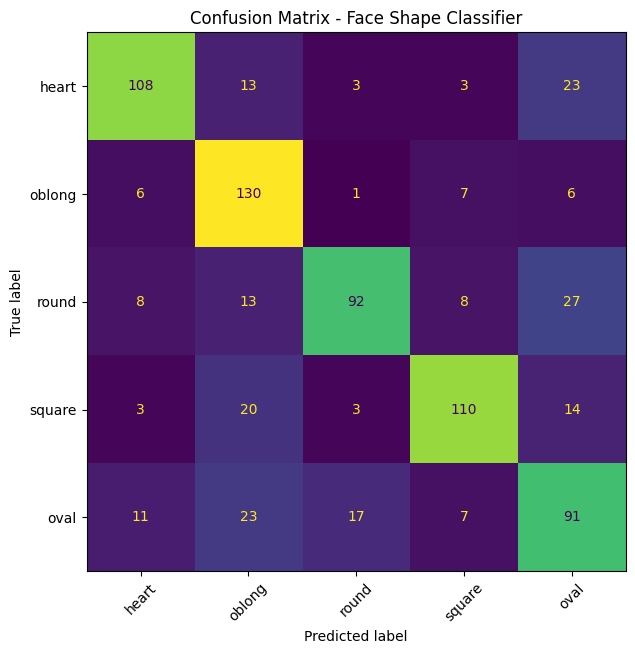

In [26]:
# ==========================
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test loss : {test_loss:.4f}")
print(f"Test acc  : {test_acc:.4f}")

y_true = test_df["target"].values
y_prob = model.predict(test_ds, verbose=1)
y_pred = y_prob.argmax(axis=1)

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
plt.title("Confusion Matrix - Face Shape Classifier")
plt.show()


In [27]:
model.save("final_face_shape_model.keras")

In [ ]:
# ==========================
FINAL_MODEL_DIR = "/content/models/final_face_shape_model"
model.save(FINAL_MODEL_DIR)

with open("/content/models/label_map.json", "w") as f:
    json.dump(idx_to_label, f, indent=2)

print("Saved model to:", FINAL_MODEL_DIR)
print("Saved label map to: /content/models/label_map.json")


In [33]:
!pip install mediapipe
!pip install mediapipe==0.10.21

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 13.9 MB/s eta 0:00:00


In [1]:
import tensorflow as tf
import cv2
import mediapipe as mp
import numpy as np

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


In [22]:
model = tf.keras.models.load_model("models/best_face_shape_model.keras")
print("Model loaded")

Model loaded


In [23]:
IMG_SIZE = (224, 224)

CLASSES = ["heart","oblong","round","square","oval","diamond","pear"]

In [24]:
import cv2
import mediapipe as mp

mp_face_detection = mp.solutions.face_detection

In [25]:
import cv2
import mediapipe as mp

mp_face_detection = mp.solutions.face_detection

def crop_face_with_mediapipe(image_path, out_path="cropped.jpg", margin=0.08):
    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        raise ValueError(f"Gagal membaca gambar: {image_path}")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    with mp_face_detection.FaceDetection(
        model_selection=1,
        min_detection_confidence=0.5
    ) as detector:

        results = detector.process(image_rgb)

    if not results.detections:
        print("Wajah tidak terdeteksi, pakai gambar original")
        return image_path

    detection = results.detections[0]
    bbox = detection.location_data.relative_bounding_box

    h, w, _ = image_bgr.shape

    x1 = max(0, int((bbox.xmin - margin) * w))
    y1 = max(0, int((bbox.ymin - margin) * h))
    x2 = min(w, int((bbox.xmin + bbox.width + margin) * w))
    y2 = min(h, int((bbox.ymin + bbox.height + margin) * h))

    cropped = image_bgr[y1:y2, x1:x2]

    if cropped.size == 0:
        return image_path

    cv2.imwrite(out_path, cropped)

    return out_path

In [26]:
# ======================================================
HAIR_RECOMMENDATIONS = {
    "heart": {
        "recommended": [
            "side-swept bangs",
            "brow-grazing fringe",
            "pixie cut",
            "long layers",
            "shoulder-length waves",
        ],
        "avoid": [
            "volume berlebih di area dahi",
            "potongan yang makin melebar di cheekbone",
        ],
    },
    "square": {
        "recommended": [
            "textured shag",
            "soft waves",
            "long layers",
            "layered lob",
            "side-swept bangs",
        ],
        "avoid": [
            "blunt cut tepat di jawline",
            "fringe tebal lurus yang terlalu kaku",
        ],
    },
    "round": {
        "recommended": [
            "long bob / lob",
            "chin-length bob",
            "face-framing layers",
            "gaya dengan height di crown",
            "deep side part",
        ],
        "avoid": [
            "volume terlalu lebar di samping",
            "gaya yang membuat wajah tampak makin bulat",
        ],
    },
    "oval": {
        "recommended": [
            "hampir semua model masuk",
            "angular bob",
            "long beach waves",
            "layered cut",
            "lob",
        ],
        "avoid": [
            "volume terlalu tinggi di atas kepala jika membuat wajah terlihat lebih panjang",
        ],
    },
    "oblong": {
        "recommended": [
            "soft waves",
            "chin-length bob",
            "curtain bangs",
            "face-framing layers",
            "volume di sisi wajah",
        ],
        "avoid": [
            "rambut sangat lurus dan flat tanpa volume samping",
            "tinggi berlebih di crown",
        ],
    },
    # Optional if you switch to 7-class dataset:
    "diamond": {
        "recommended": [
            "side-swept bangs",
            "textured layers",
            "lob",
            "soft fringe",
            "volume lembut di dahi/jawline",
        ],
        "avoid": [
            "potongan yang terlalu menonjolkan lebar cheekbone",
        ],
    },
    "pear": {
        "recommended": [
            "layered cut dengan volume di atas",
            "side-swept bangs",
            "wavy lob",
            "shoulder-length layers",
            "curtain bangs",
        ],
        "avoid": [
            "volume berat di area rahang",
        ],
    },
}

def preprocess_single_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image

def predict_face_shape(image_path, auto_crop=True):
    working_path = image_path
    if auto_crop:
        working_path = crop_face_with_mediapipe(image_path)

    image = preprocess_single_image(working_path)
    probs = model.predict(tf.expand_dims(image, axis=0), verbose=0)[0]

    top_idx = int(np.argmax(probs))
    predicted_label = idx_to_label[top_idx]

    top3 = sorted(
        [(idx_to_label[i], float(probs[i])) for i in range(len(probs))],
        key=lambda x: x[1],
        reverse=True,
    )[:3]

    return predicted_label, top3, HAIR_RECOMMENDATIONS.get(predicted_label, {}), working_path


In [27]:
CLASSES = ["heart","oblong","round","square","oval",]

label_to_idx = {label: i for i, label in enumerate(CLASSES)}
idx_to_label = {i: label for label, i in label_to_idx.items()}

In [28]:
pred_label, top3, recs, used_image_path = predict_face_shape(test_image_path, auto_crop=True)

Upload foto wajah untuk inferensi


Saving 33ebaea77d0cc865c98a28f964f54ac4.jpg to 33ebaea77d0cc865c98a28f964f54ac4 (5).jpg

Predicted face shape: heart

Top-3 probabilities:
- heart: 0.8108
- oblong: 0.0903
- oval: 0.0502

Recommended hairstyles:
- side-swept bangs
- brow-grazing fringe
- pixie cut
- long layers
- shoulder-length waves

Avoid / caution:
- volume berlebih di area dahi
- potongan yang makin melebar di cheekbone


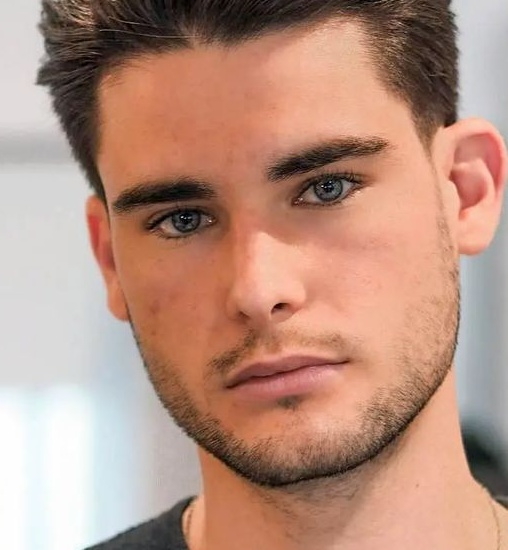

In [38]:

from google.colab import files
from IPython.display import display, Image as IPyImage

print("Upload foto wajah untuk inferensi")
uploaded_test = files.upload()
test_image_path = next(iter(uploaded_test.keys()))

pred_label, top3, recs, used_image_path = predict_face_shape(test_image_path, auto_crop=True)

print("\nPredicted face shape:", pred_label)
print("\nTop-3 probabilities:")
for label, score in top3:
    print(f"- {label}: {score:.4f}")

print("\nRecommended hairstyles:")
for item in recs.get("recommended", []):
    print(f"- {item}")

print("\nAvoid / caution:")
for item in recs.get("avoid", []):
    print(f"- {item}")

display(IPyImage(filename=used_image_path))


In [ ]:
# ===========================================================
# 16) (Optional) Export simple CSV prediction log in /content

In [34]:
# ===========================================================
log_path = "/content/prediction_log.csv"
pred_log = pd.DataFrame(
    [
        {
            "image_path": test_image_path,
            "predicted_face_shape": pred_label,
            "top3": json.dumps(top3),
            "recommended": json.dumps(recs.get("recommended", []), ensure_ascii=False),
            "avoid": json.dumps(recs.get("avoid", []), ensure_ascii=False),
        }
    ]
)
pred_log.to_csv(log_path, index=False)
print("\nPrediction log saved to:", log_path)


Prediction log saved to: /content/prediction_log.csv
